# SR-PDS simulation - quick laptop run

Sanity-checks the full pipeline before committing HPC time. Runs every
DGP and every estimator at a small replication count, builds every
output figure, and writes everything to `../results_quick/`.

Expected runtime on a recent MacBook: roughly 45-90 minutes. SR-PDS is
the bottleneck (~20s per fit, 2 fits per replication for vanilla
SR-PDS, 10 fits per replication for SR-PDS-CF).

Run this end-to-end first. If anything crashes or any plot looks wrong,
fix it here rather than queueing the full HPC job.


## 1. Setup

In [ ]:
import os
import sys
import pickle
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')

from dgp import DGP_REGISTRY
from estimators import ESTIMATOR_REGISTRY, SR_PDS_LOG
from simulation import run_all, run_simulation
from evaluate import (evaluate_all, summary_table, print_summary,
                      evaluate_recovery)
from plots import (plot_bias, plot_coverage, plot_rmse_heatmap,
                   plot_summary_panel, plot_distributions,
                   plot_recovery_heatmap, plot_coefficient_recovery,
                   plot_n_trajectory, plot_recovery_vs_n)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 90

N           = 500
P           = 50
S           = 6
BETA0       = 0.5
N_REPS      = 10        # small for laptop - this is the whole point of the quick notebook
N_REPS_CF   = 5         # cross-fit is 5x more expensive per rep
N_JOBS      = 4         # outer parallelism, ignored by the SR-PDS estimators
RESULTS_DIR = '../results_quick'

os.makedirs(RESULTS_DIR, exist_ok=True)
DGP_KEYS = list(DGP_REGISTRY.keys())
EST_KEYS = list(ESTIMATOR_REGISTRY.keys())

print(f"DGPs ({len(DGP_KEYS)}):       {DGP_KEYS}")
print(f"Estimators ({len(EST_KEYS)}): {EST_KEYS}")
print(f"N={N}, p={P}, n_reps={N_REPS} (sr_pds_cf at {N_REPS_CF})")

DGPs (8):       ['dgp1', 'dgp2', 'dgp3', 'dgp4', 'dgp5', 'dgp6', 'dgp7', 'dgp8']
Estimators (7): ['full_ols', 'pds_lasso', 'dml_lasso', 'dml_rf', 'dml_nn', 'sr_pds', 'sr_pds_cf']
N=500, p=50, n_reps=10 (sr_pds_cf at 5)


## 2. DGP exploration

Quick check that all eight DGPs generate sensible data. The summary
shows the standard deviation of y, the standard deviation of d, and
whether the propensity has a non-trivial structure.

In [2]:
print(f"{'DGP':<6} {'label':<26} {'E[y]':>8} {'std[y]':>8} {'std[d]':>8} {'conf':<6}")
print('-' * 70)
for key, entry in DGP_REGISTRY.items():
    X, d, y, _ = entry['fn'](n=2000, p=P, s=S, beta0=BETA0)
    has_conf = 'yes' if entry['truth_terms_d'] else ('linear' if d.std() > 1.2 else 'no')
    print(f"{key:<6} {entry['label']:<26} {y.mean():>8.2f} {y.std():>8.2f} "
          f"{d.std():>8.2f} {has_conf:<6}")

DGP    label                          E[y]   std[y]   std[d] conf  
----------------------------------------------------------------------
dgp1   Linear                        -0.37     8.40     1.01 no    
dgp2   Quadratic                      7.32    10.13     1.01 no    
dgp3   Interactions                  -0.09     8.16     1.01 no    
dgp4   Mixed nonlinear                3.52    10.72     1.01 no    
dgp5   NL + linear conf.              3.52    10.83     2.61 linear
dgp6   NL + mild NL conf.             3.51    11.02     2.26 yes   
dgp7   NL + severe NL conf.           3.55    12.45     4.55 yes   
dgp8   Weak NL conf. (dummies)        3.46    10.90     1.12 yes   


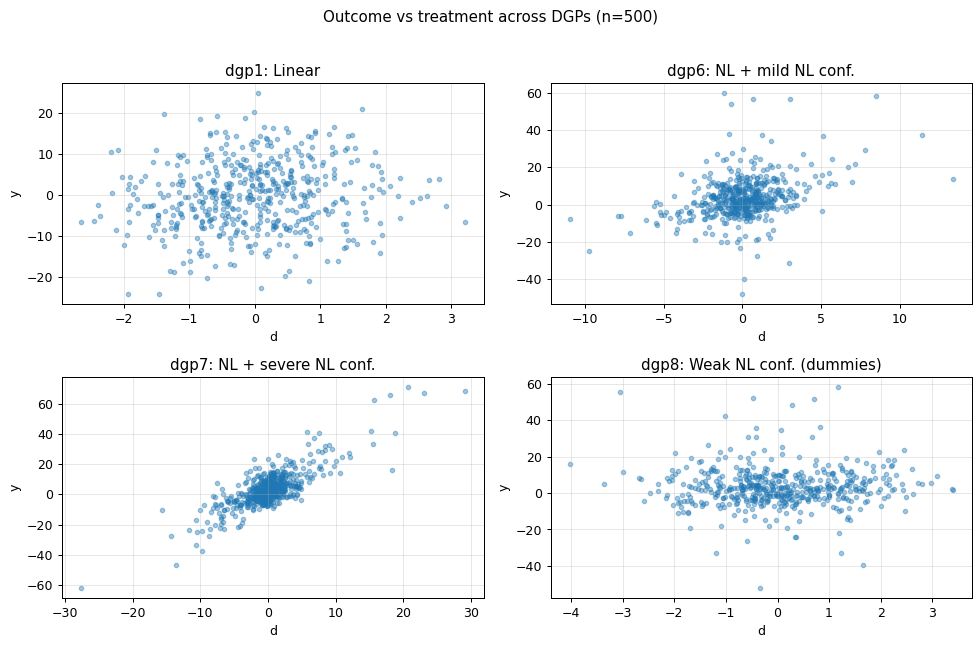

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, key in zip(axes.flat, ['dgp1', 'dgp6', 'dgp7', 'dgp8']):
    X, d, y, _ = DGP_REGISTRY[key]['fn'](n=500, p=P, s=S, beta0=BETA0)
    ax.scatter(d, y, alpha=0.4, s=12)
    ax.set_xlabel('d')
    ax.set_ylabel('y')
    ax.set_title(f"{key}: {DGP_REGISTRY[key]['label']}")
    ax.grid(alpha=0.3)
plt.suptitle('Outcome vs treatment across DGPs (n=500)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Smoke test

Verify each estimator returns a sensible result before launching the
full Monte Carlo. The standard methods are tested across all DGPs in
one go; the SR-PDS methods get a single run on DGP-6 because they're
expensive.

In [4]:
from estimators import full_ols, pds_lasso, dml_lasso, dml_rf, dml_nn

print(f"True beta0 = {BETA0}\n")
print(f"{'DGP':<6} {'Full':>8} {'PDS-L':>8} {'DML-L':>8} {'DML-RF':>8} {'DML-NN':>8}")
print('-' * 56)
for key, entry in DGP_REGISTRY.items():
    X, d, y, _ = entry['fn'](n=N, p=P, s=S, beta0=BETA0, seed=42)
    row = [key]
    for est in (full_ols, pds_lasso, dml_lasso, dml_rf, dml_nn):
        try:
            r = est(X, d, y, N, P)
            row.append(f"{r['beta_hat']:>+.3f}")
        except Exception:
            row.append('FAIL')
    print(f"{row[0]:<6} {row[1]:>8} {row[2]:>8} {row[3]:>8} {row[4]:>8} {row[5]:>8}")

True beta0 = 0.5

DGP        Full    PDS-L    DML-L   DML-RF   DML-NN
--------------------------------------------------------
dgp1     +0.468   +0.461   +0.497   +0.614   +0.560
dgp2     +0.758   +0.735   +0.785   +0.713   +0.961
dgp3     +0.561   +0.538   +0.576   +0.624   +1.063
dgp4     +0.201   +0.208   +0.192   +0.568   +0.096
dgp5     +0.201   +0.195   +0.182   +0.713   +0.621
dgp6     +1.621   +1.589   +1.579   +1.768   +1.639
dgp7     +1.995   +1.994   +2.001   +1.772   +2.024
dgp8     +0.385   +0.366   +0.391   +0.736   +0.357


In [5]:
# single SR-PDS run on DGP-6. Should discover x4*x5 in d (the confounder)
# and the mixed-nonlinear terms in y.
from estimators import sr_pds

X, d, y, _ = DGP_REGISTRY['dgp6']['fn'](n=300, p=P, s=S, beta0=BETA0, seed=42)
result = sr_pds(X, d, y, 300, P, log=False, debug=False)

print(f"DGP-6 single SR-PDS run (n=300):")
print(f"  beta_hat = {result['beta_hat']:.4f}  (true = {BETA0})")
print(f"  CI       = [{result['ci_low']:.3f}, {result['ci_high']:.3f}]")
print(f"  pre-LASSO  y: {result['pre_lasso_terms_y']}")
print(f"  pre-LASSO  d: {result['pre_lasso_terms_d']}")
print(f"  post-LASSO y: {result['post_lasso_terms_y']}")
print(f"  post-LASSO d: {result['post_lasso_terms_d']}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
DGP-6 single SR-PDS run (n=300):
  beta_hat = 0.7779  (true = 0.5)
  CI       = [-0.155, 1.711]
  pre-LASSO  y: []
  pre-LASSO  d: [('int', 3, 4)]
  post-LASSO y: []
  post-LASSO d: [('int', 3, 4)]


## 4. Headline Monte Carlo

All 8 DGPs x all 7 estimators at n=500. We use `reps_overrides` to
cap sr_pds_cf at half the rep count of everything else since cross-fit
is 5x more expensive per rep.

In [6]:
SR_PDS_LOG.clear()

combined = run_all(
    dgp_registry       = DGP_REGISTRY,
    estimator_registry = ESTIMATOR_REGISTRY,
    dgp_keys           = DGP_KEYS,
    estimator_keys     = EST_KEYS,
    n                  = N,
    p                  = P,
    s                  = S,
    beta0              = BETA0,
    n_reps             = N_REPS,
    n_jobs             = N_JOBS,
    save_dir           = RESULTS_DIR,
    reps_overrides     = {'sr_pds_cf': N_REPS_CF},
)

combined.to_pickle(f'{RESULTS_DIR}/headline.pkl')
with open(f'{RESULTS_DIR}/sr_pds_log.pkl', 'wb') as f:
    pickle.dump(list(SR_PDS_LOG), f)
print(f"\nSaved headline + log to {RESULTS_DIR}")


[  0.0 min]  Linear x Full OLS  (n_jobs=4, n_reps=10)



[  0.0 min]  Linear x PDS-LASSO  (n_jobs=4, n_reps=10)



[  0.0 min]  Linear x DML-LASSO  (n_jobs=4, n_reps=10)



[  0.0 min]  Linear x DML-RF  (n_jobs=4, n_reps=10)



[  0.9 min]  Linear x DML-NN  (n_jobs=4, n_reps=10)


...


[ 30.5 min]  Weak NL conf. (dummies) x DML-RF  (n_jobs=4, n_reps=10)



[ 31.9 min]  Weak NL conf. (dummies) x DML-NN  (n_jobs=4, n_reps=10)



[ 32.0 min]  Weak NL conf. (dummies) x SR-PDS  (n_jobs=1, n_reps=10)



[ 33.0 min]  Weak NL conf. (dummies) x SR-PDS (CF)  (n_jobs=1, n_reps=5)



All results saved to ../results_quick/all_results.csv
SR-PDS log (120 entries) saved to ../results_quick/sr_pds_log.pkl

Total time: 35.4 min

Saved headline + log to ../results_quick


## 5. Bias / RMSE / coverage / size

These are the four canonical metrics. Coverage and size are reported
as percentages; bias and RMSE are on the same scale as beta0.

In [7]:
all_metrics = evaluate_all(combined, beta0=BETA0)
print_summary(all_metrics, BETA0)


True ATE: 0.5

BIAS
------------------------------------------------------------
                         DML-LASSO  DML-NN  DML-RF  Full OLS  PDS-LASSO  SR-PDS  SR-PDS (CF)
DGP                                                                                         
Interactions                0.0060  0.1148 -0.0104    0.0085     0.0023  0.0021      -0.0477
Linear                     -0.0187  0.0544 -0.0975   -0.0053    -0.0066 -0.0072      -0.0288
Mixed nonlinear             0.1119  0.2159  0.0834    0.1028     0.0800 -0.0096      -0.0351
NL + linear conf.           0.1154  0.2378 -0.1644    0.1028     0.0818  0.0367      -0.0513
NL + mild NL conf.          1.2625  1.2036  1.3079    1.2430     1.2179  0.0576      -0.0173
NL + severe NL conf.        1.5938  1.5280  1.3994    1.5611     1.5505 -0.0251       0.3876
Quadratic                  -0.1174 -0.0767 -0.1077   -0.1161    -0.1282 -0.0875      -0.1320
Weak NL conf. (dummies)     0.7792  0.8338  0.6480    0.7504     0.7120  0.1499  

  Saved: ../figures/bias.png


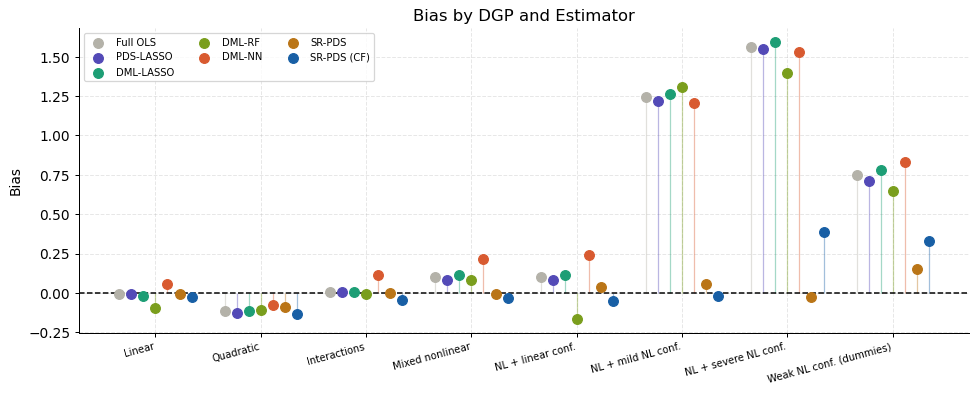

  Saved: ../figures/coverage.png


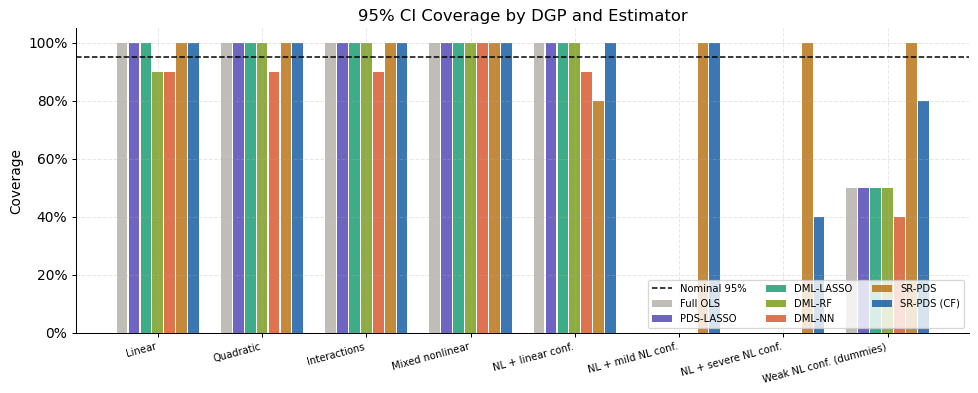

  Saved: ../figures/rmse_heatmap.png


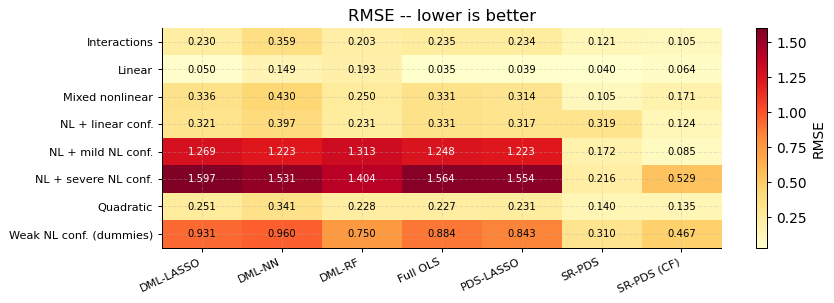

  Saved: ../figures/summary_panel.png


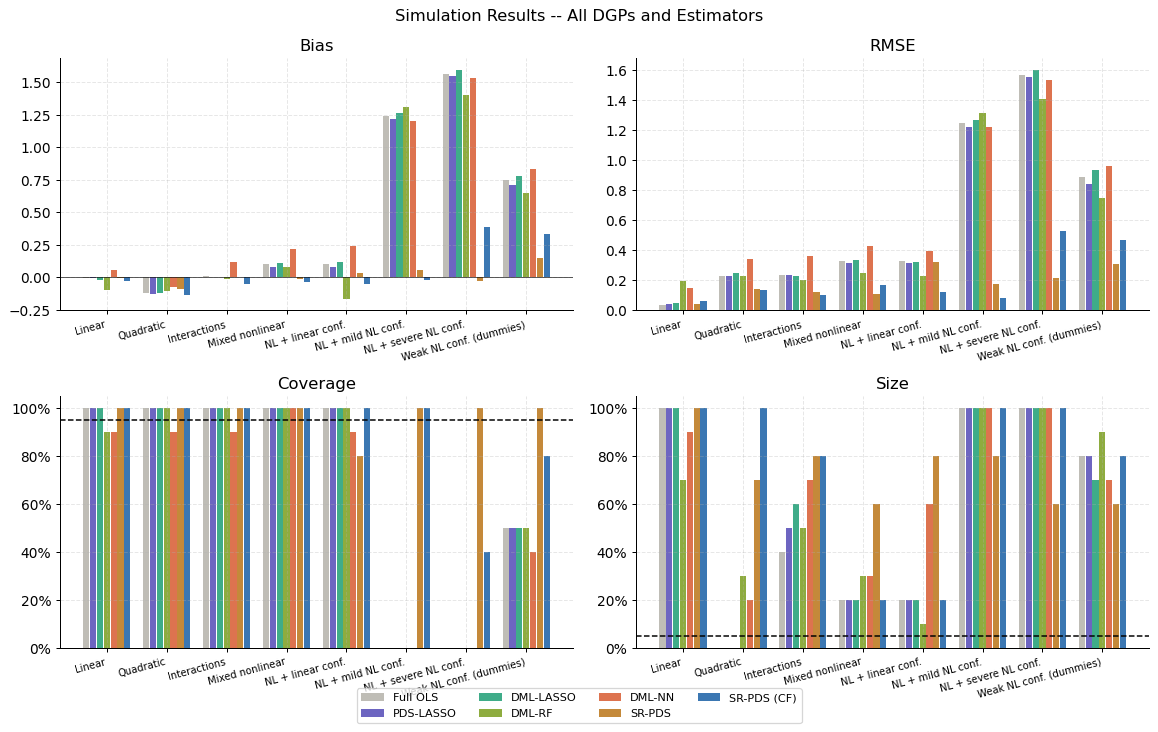

In [8]:
plot_bias(all_metrics, save=True);          plt.show()
plot_coverage(all_metrics, save=True);      plt.show()
plot_rmse_heatmap(all_metrics, save=True);  plt.show()
plot_summary_panel(all_metrics, save=True); plt.show()

  Saved: ../figures/dist_dgp1.png


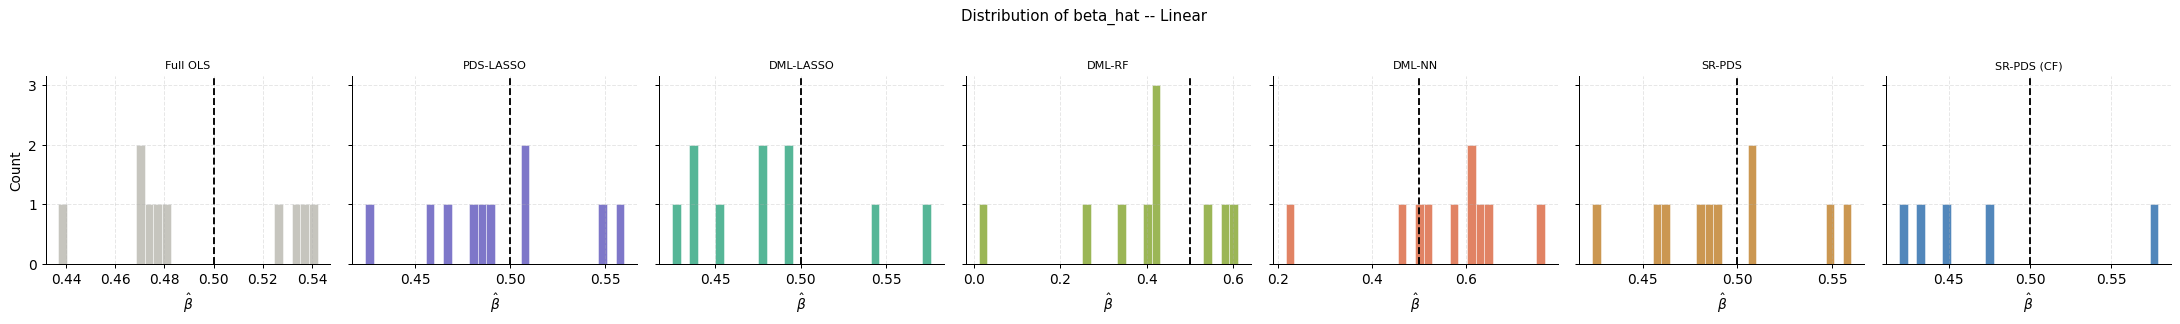

  Saved: ../figures/dist_dgp2.png


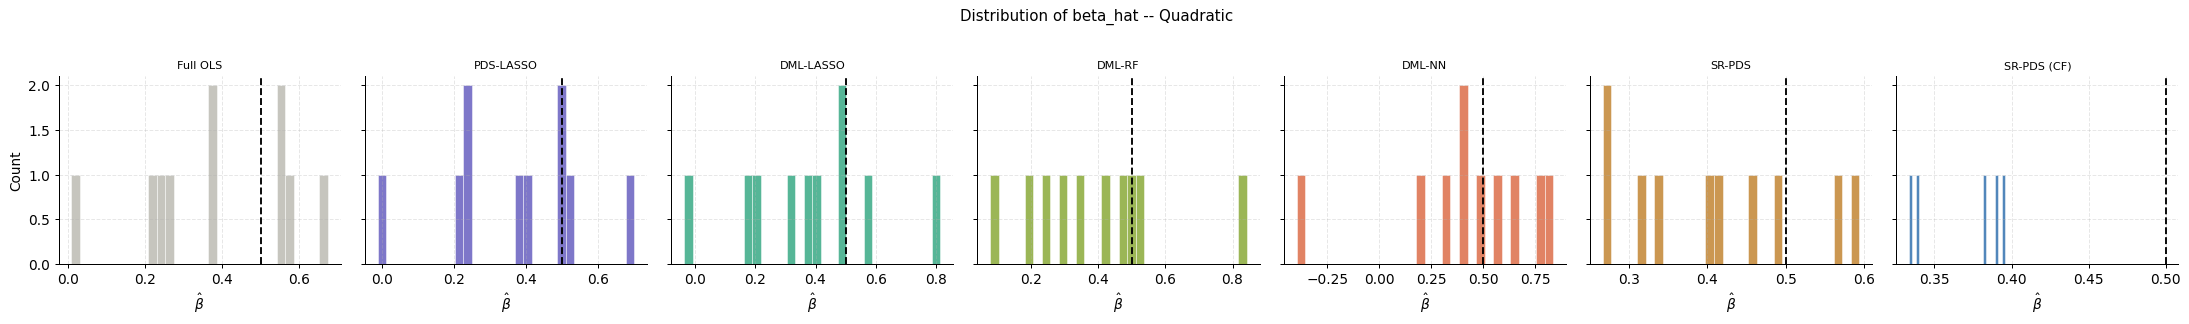

  Saved: ../figures/dist_dgp3.png


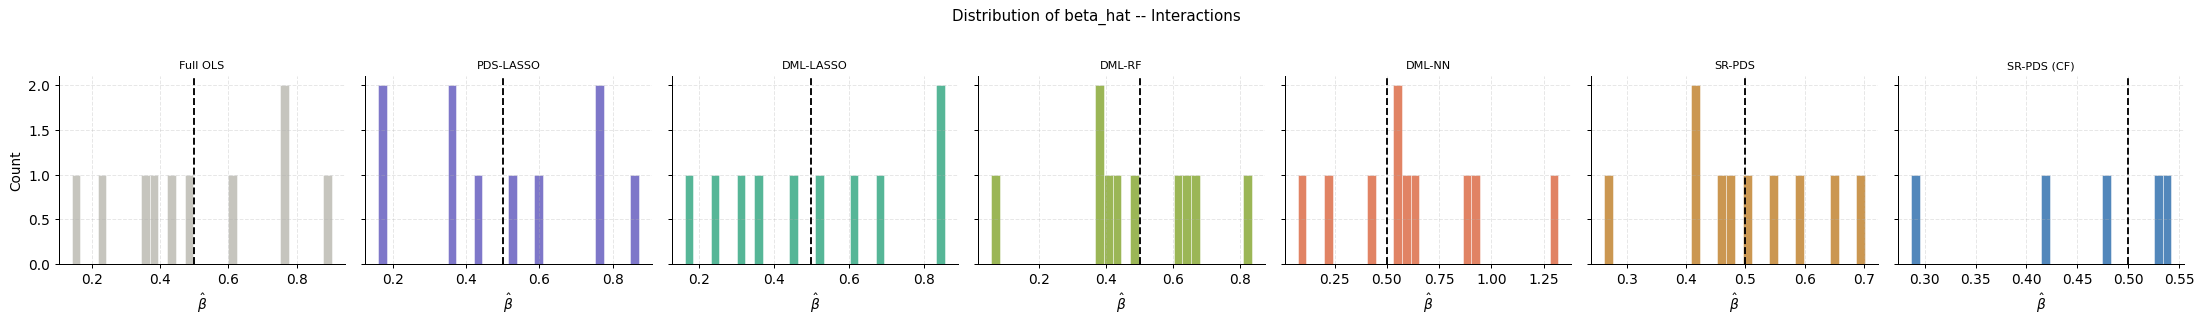

  Saved: ../figures/dist_dgp4.png


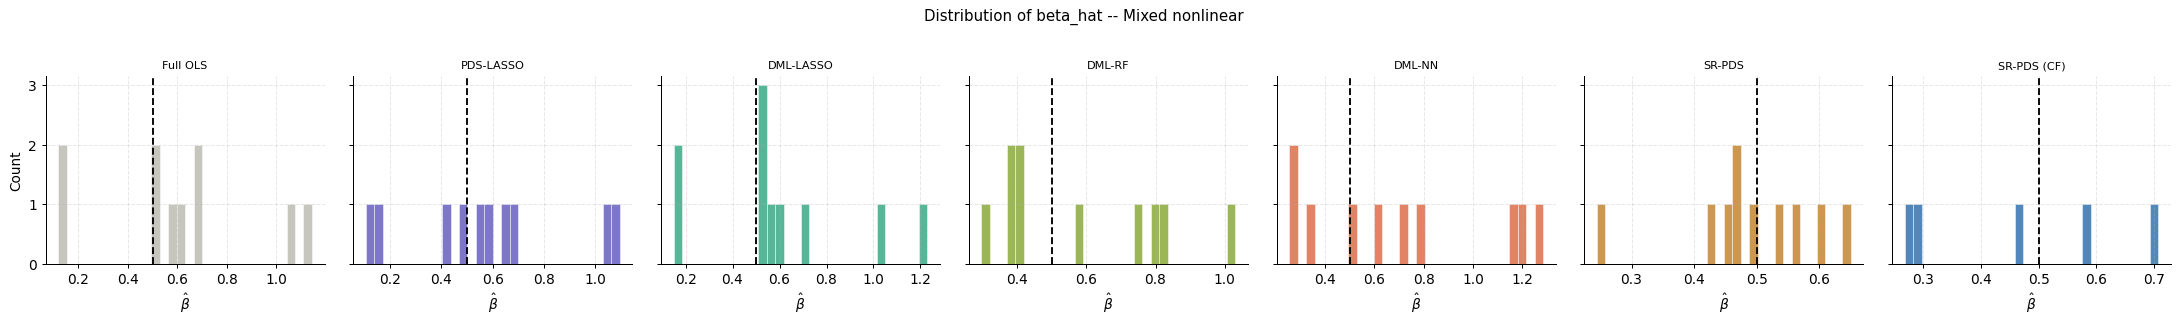

  Saved: ../figures/dist_dgp5.png


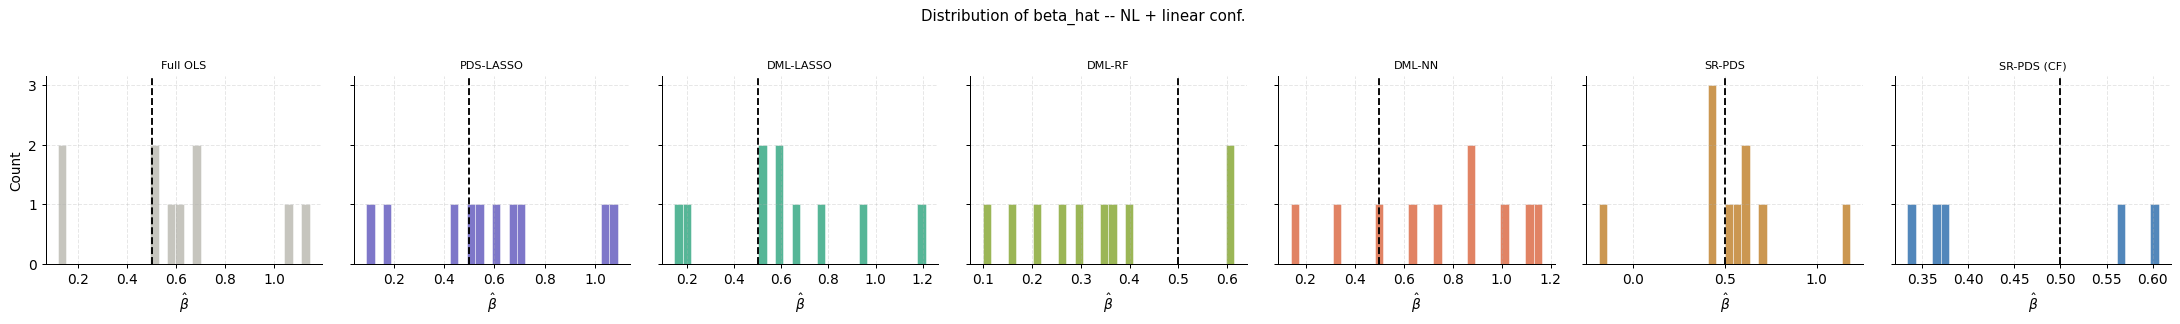

  Saved: ../figures/dist_dgp6.png


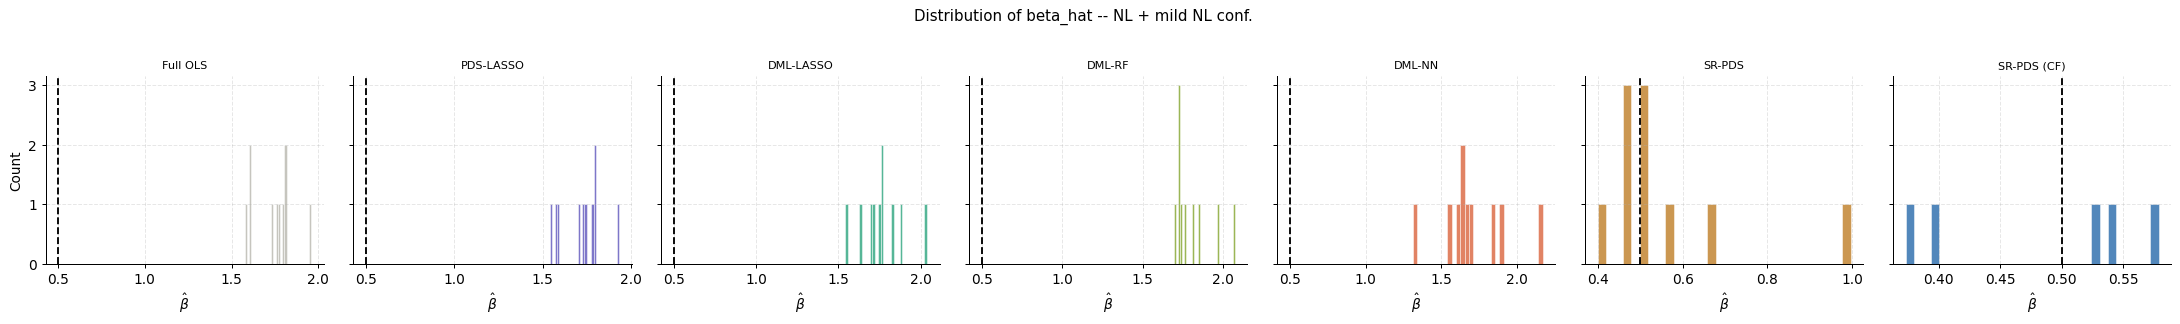

  Saved: ../figures/dist_dgp7.png


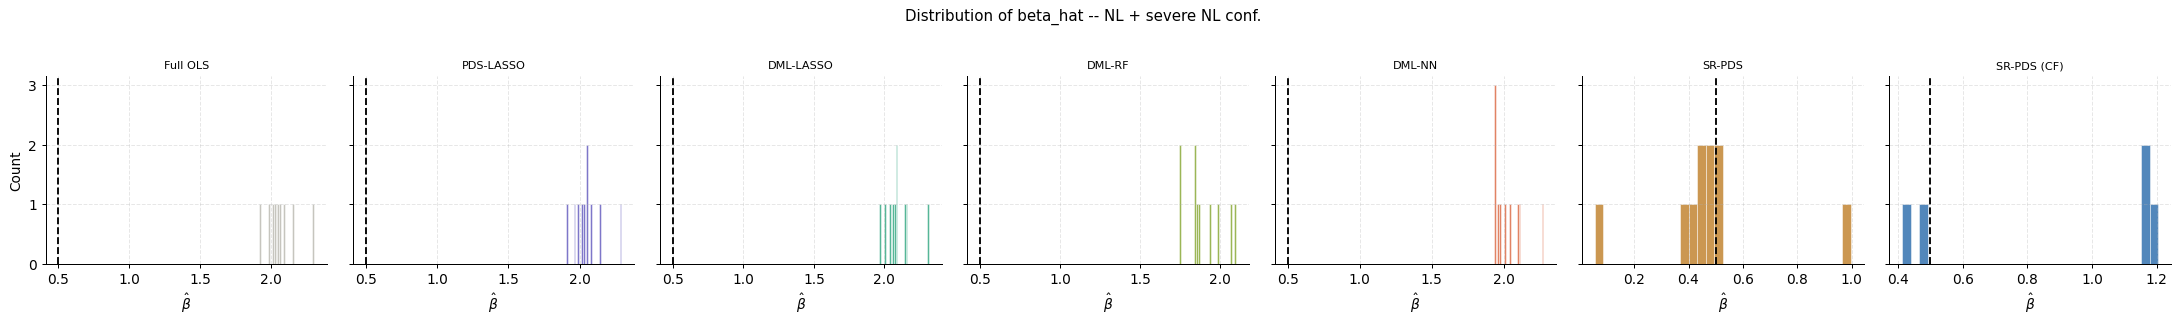

  Saved: ../figures/dist_dgp8.png


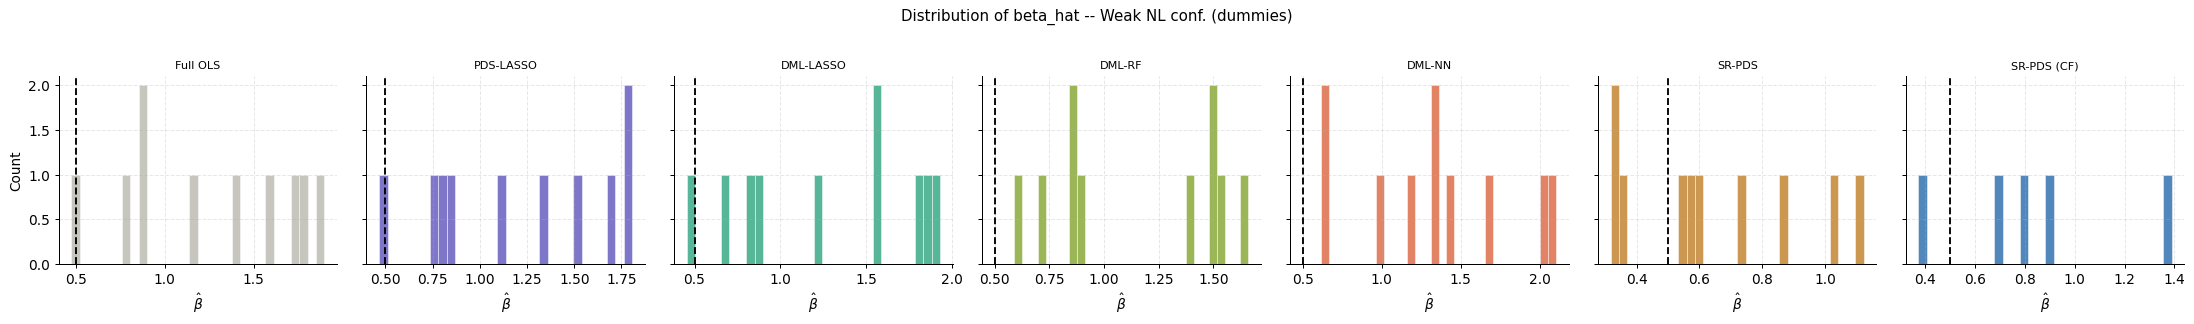

In [ ]:
# per-DGP histograms - look for bimodality or heavy tails that the
# point estimates would otherwise hide
for dgp_key in DGP_KEYS:
    fig = plot_distributions(combined, BETA0, dgp_key, save=True)
    plt.show()

## 6. Recovery analysis

How often did PySR actually discover the true nonlinear terms, and
how often did those discoveries survive the downstream LASSO step?

This only makes sense on DGPs that have non-trivial nonlinear truth.

In [10]:
recovery_df = evaluate_recovery(list(SR_PDS_LOG), DGP_REGISTRY)
print(f"Recovery records: {len(recovery_df)}")
recovery_df.head(20)

Recovery records: 96


,dgp,dgp_label,variant,equation,term,term_label,stage,recovery_rate,n_reps,true_coef,mean_coef,std_coef,coef_bias,coef_rmse
0,dgp2,Quadratic,sr_pds,y,"(sq, 0, None)",x0^2,pre_lasso,1.0,10,5.0,NaN,NaN,NaN,NaN
1,dgp2,Quadratic,sr_pds,y,"(sq, 0, None)",x0^2,post_lasso,1.0,10,5.0,4.981575,0.086498,-0.018425,0.088439
2,dgp2,Quadratic,sr_pds,y,"(sq, 2, None)",x2^2,pre_lasso,0.3,10,3.0,NaN,NaN,NaN,NaN
3,dgp2,Quadratic,sr_pds,y,"(sq, 2, None)",x2^2,post_lasso,0.3,10,3.0,3.024791,0.007448,0.024791,0.025885
4,dgp2,Quadratic,sr_pds_cf,y,"(sq, 0, None)",x0^2,pre_lasso,1.0,5,5.0,NaN,NaN,NaN,NaN
5,dgp2,Quadratic,sr_pds_cf,y,"(sq, 0, None)",x0^2,post_lasso,1.0,5,5.0,NaN,NaN,NaN,NaN
6,dgp2,Quadratic,sr_pds_cf,y,"(sq, 2, None)",x2^2,pre_lasso,1.0,5,3.0,NaN,NaN,NaN,NaN
7,dgp2,Quadratic,sr_pds_cf,y,"(sq, 2, None)",x2^2,post_lasso,1.0,5,3.0,NaN,NaN,NaN,NaN
8,dgp3,Interactions,sr_pds,y,"(int, 0, 1)",x0*x1,pre_lasso,0.7,10,5.0,NaN,NaN,NaN,NaN
9,dgp3,Interactions,sr_pds,y,"(int, 0, 1)",x0*x1,post_lasso,0.7,10,5.0,4.854422,0.181911,-0.145578,0.232990


  Saved: ../figures/recovery_heatmap_y.png


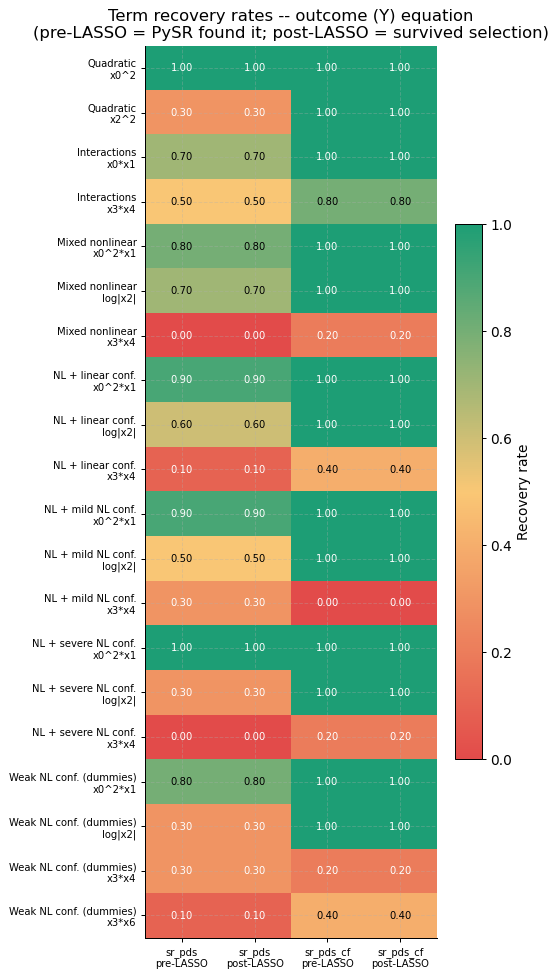

  Saved: ../figures/recovery_heatmap_d.png


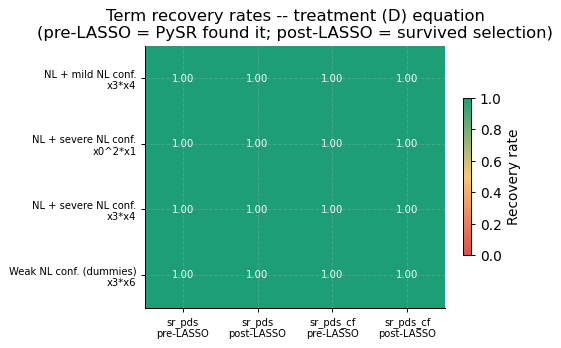

  Saved: ../figures/coef_recovery_y.png


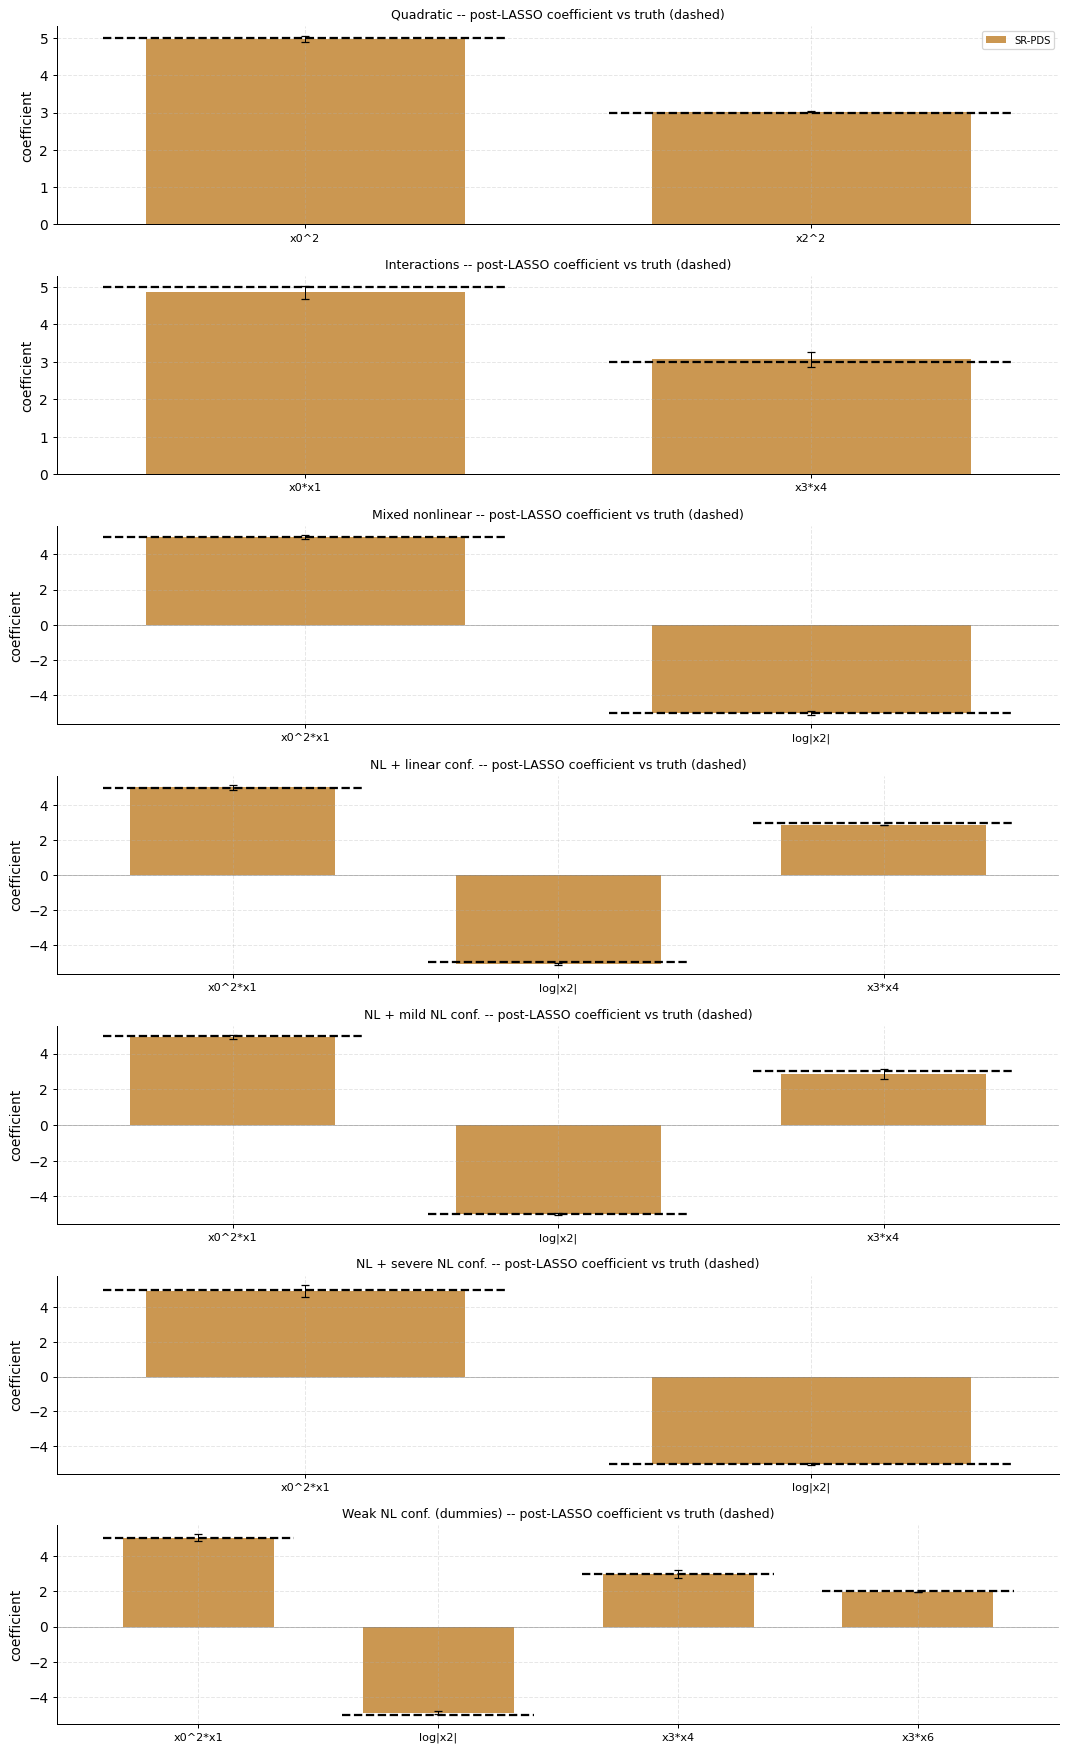

In [11]:
if not recovery_df.empty:
    plot_recovery_heatmap(recovery_df, equation='y', save=True); plt.show()
    sub_d = recovery_df[recovery_df['equation'] == 'd']
    if not sub_d.empty:
        plot_recovery_heatmap(recovery_df, equation='d', save=True); plt.show()
    plot_coefficient_recovery(recovery_df, equation='y', save=True); plt.show()

## 7. Abbreviated trajectory

A short trajectory at n in {30, 100, 500, 2000} to verify the trajectory
pipeline works end-to-end. The full trajectory (n=30 through n=50,000)
lives in `main_full.ipynb`. SR-PDS-CF is excluded because we only run
it at the headline n=500.

In [12]:
N_GRID        = [30, 100, 500, 2000]
N_REPS_TRAJ   = 5
TRAJ_EST_KEYS = [k for k in EST_KEYS if k != 'sr_pds_cf']

SR_PDS_LOG.clear()
traj_rows = []
total = len(N_GRID) * len(DGP_KEYS) * len(TRAJ_EST_KEYS)
i = 0
for n_grid in N_GRID:
    for dgp_key in DGP_KEYS:
        for est_key in TRAJ_EST_KEYS:
            i += 1
            est = ESTIMATOR_REGISTRY[est_key]
            print(f"[{i}/{total}] n={n_grid:>5} {dgp_key} {est_key}", end='  ')
            df = run_simulation(
                DGP_REGISTRY[dgp_key]['fn'], est['fn'],
                estimator_key=est_key,
                n=n_grid, p=P, s=S, beta0=BETA0,
                n_reps=N_REPS_TRAJ,
                n_jobs=1 if est['requires_serial'] else N_JOBS,
                dgp_key=dgp_key,
            )
            df['dgp'] = dgp_key
            df['estimator'] = est_key
            df['dgp_label'] = DGP_REGISTRY[dgp_key]['label']
            df['est_label'] = est['label']
            df['beta0'] = BETA0
            df['n_grid'] = n_grid
            traj_rows.append(df)
            print(f"  beta={df['beta_hat'].mean():+.3f}")

traj_df = pd.concat(traj_rows, ignore_index=True)
traj_df.to_pickle(f'{RESULTS_DIR}/trajectory.pkl')
print(f"\nTrajectory saved to {RESULTS_DIR}/trajectory.pkl")

[1/192] n=   30 dgp1 full_ols  

  beta=+0.566
[2/192] n=   30 dgp1 pds_lasso  

  beta=+0.566
[3/192] n=   30 dgp1 dml_lasso  

  beta=+0.193
[4/192] n=   30 dgp1 dml_rf  

  beta=-0.440
[5/192] n=   30 dgp1 dml_nn  

...

  beta=+1.254
[189/192] n= 2000 dgp8 dml_lasso  

  beta=+1.263
[190/192] n= 2000 dgp8 dml_rf  

  beta=+0.859
[191/192] n= 2000 dgp8 dml_nn  

  beta=+1.144
[192/192] n= 2000 dgp8 sr_pds  

  beta=+0.457

Trajectory saved to ../results_quick/trajectory.pkl


  Saved: ../figures/n_trajectory.png


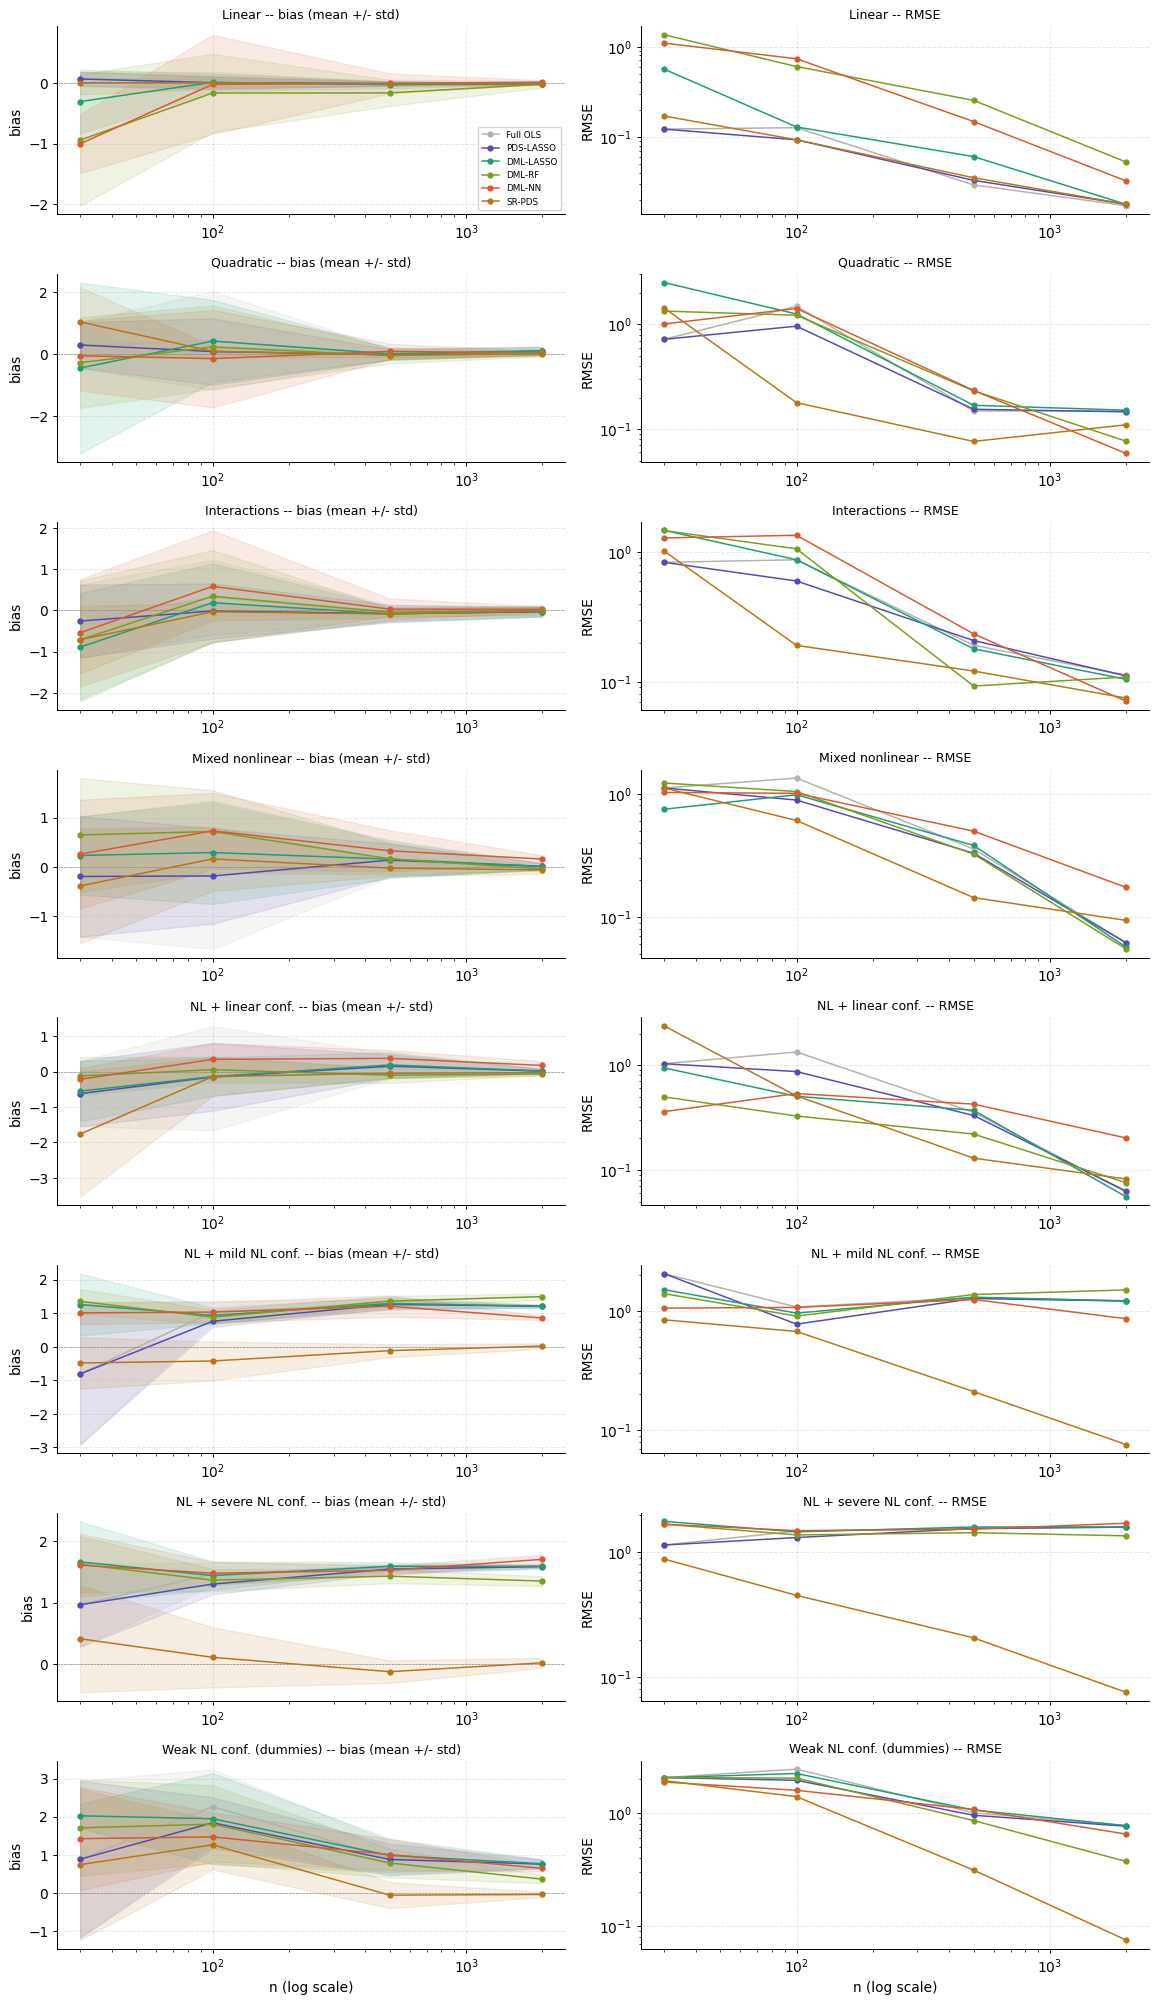

  Saved: ../figures/recovery_vs_n.png


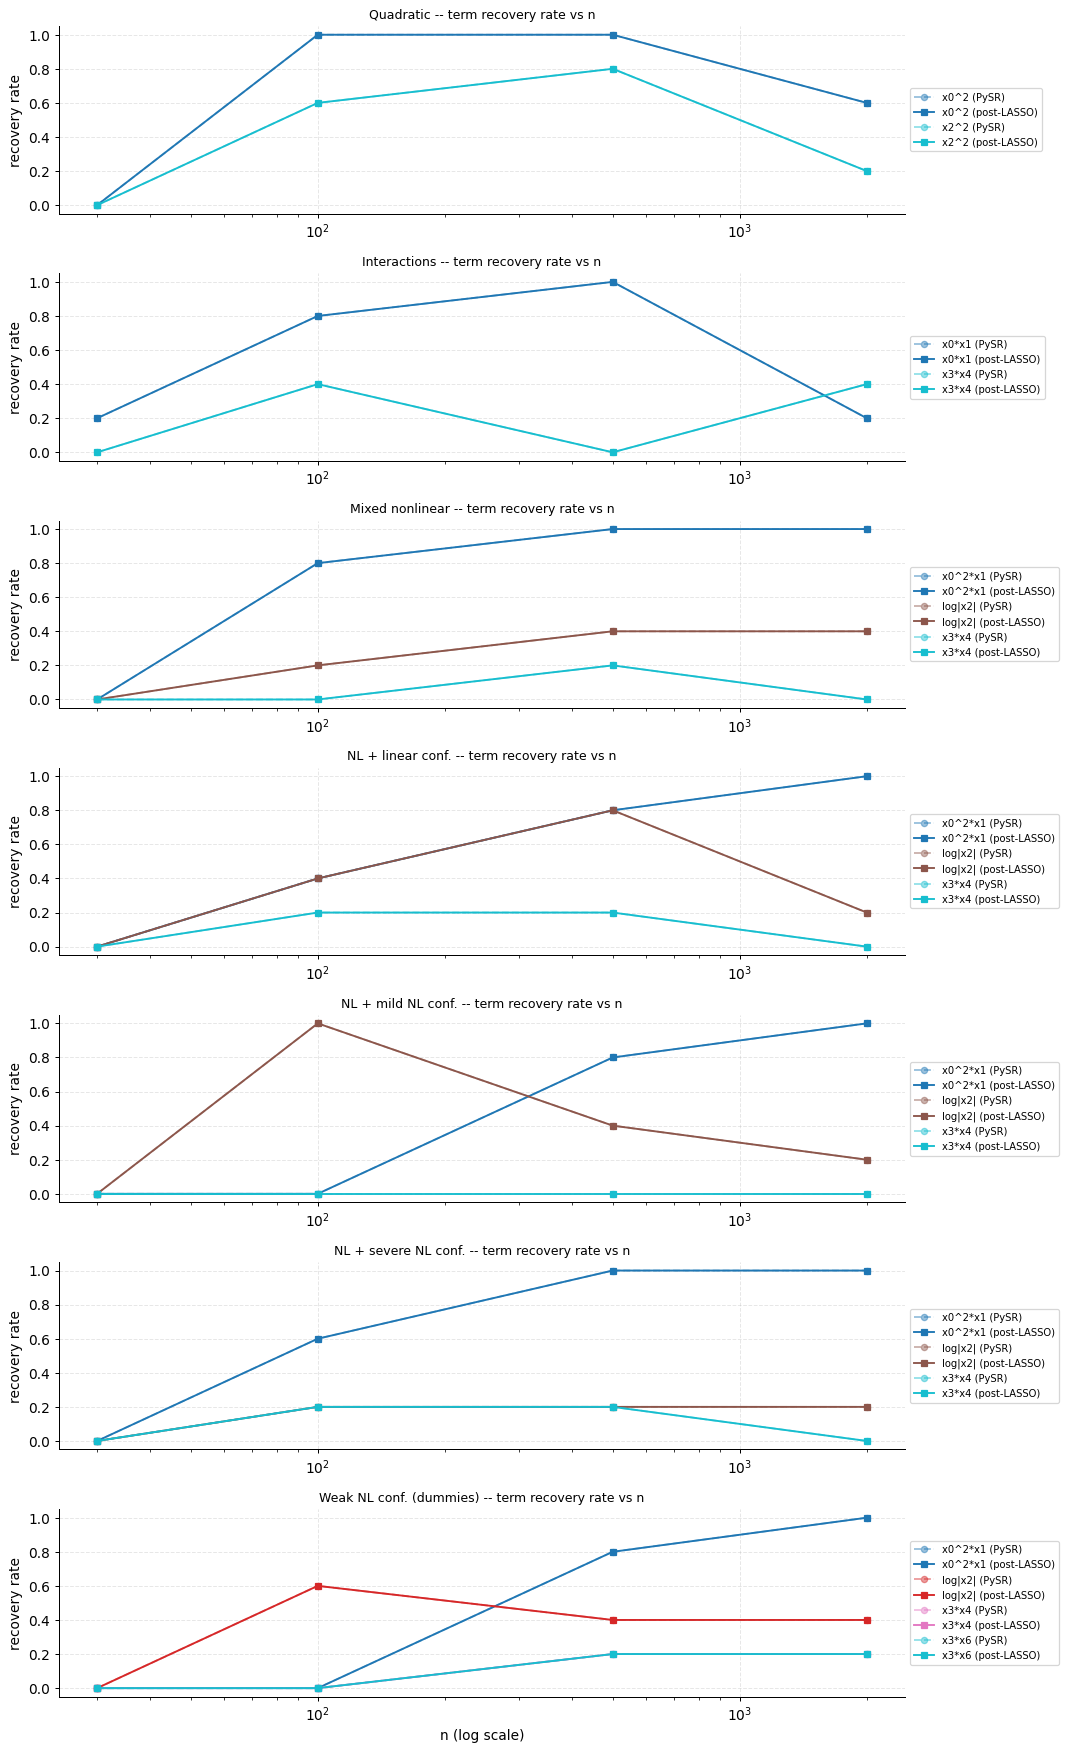

In [13]:
plot_n_trajectory(traj_df, BETA0, save=True);          plt.show()
plot_recovery_vs_n(traj_df, DGP_REGISTRY, save=True); plt.show()

## 8. Output summary

In [14]:
tag = datetime.datetime.now().strftime('%Y%m%d_%H%M')
print(f"Run tag: {tag}\n")
print(f"Files in {RESULTS_DIR}:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {f}")

Run tag: 20260605_1750

Files in ../results_quick:
  all_results.csv
  dgp1_dml_lasso.csv
  dgp1_dml_nn.csv
  dgp1_dml_rf.csv
  dgp1_full_ols.csv
  dgp1_pds_lasso.csv
  dgp1_sr_pds.csv
  dgp1_sr_pds_cf.csv
  dgp2_dml_lasso.csv
  dgp2_dml_nn.csv
  dgp2_dml_rf.csv
  dgp2_full_ols.csv
  dgp2_pds_lasso.csv
  dgp2_sr_pds.csv
  dgp2_sr_pds_cf.csv
  dgp3_dml_lasso.csv
  dgp3_dml_nn.csv
  dgp3_dml_rf.csv
  dgp3_full_ols.csv
  dgp3_pds_lasso.csv
  dgp3_sr_pds.csv
  dgp3_sr_pds_cf.csv
  dgp4_dml_lasso.csv
  dgp4_dml_nn.csv
  dgp4_dml_rf.csv
  dgp4_full_ols.csv
  dgp4_pds_lasso.csv
  dgp4_sr_pds.csv
  dgp4_sr_pds_cf.csv
  dgp5_dml_lasso.csv
  dgp5_dml_nn.csv
  dgp5_dml_rf.csv
  dgp5_full_ols.csv
  dgp5_pds_lasso.csv
  dgp5_sr_pds.csv
  dgp5_sr_pds_cf.csv
  dgp6_dml_lasso.csv
  dgp6_dml_nn.csv
  dgp6_dml_rf.csv
  dgp6_full_ols.csv
  dgp6_pds_lasso.csv
  dgp6_sr_pds.csv
  dgp6_sr_pds_cf.csv
  dgp7_dml_lasso.csv
  dgp7_dml_nn.csv
  dgp7_dml_rf.csv
  dgp7_full_ols.csv
  dgp7_pds_lasso.csv
  dgp7_sr_p